### Reading Resutls

In [8]:
import os
import glob
import pandas as pd
from IPython.display import display

# 1. Define your two new folder paths

folder_equal = "../results/equal_M=5000"
folder_unequal = "../results/unequal_M=5000"

cols_to_keep = ["Method", "N", "n", "Dm", "Ds", "Vm", "Vs", "Mm", "Ms", "Lm", "Ls"]
all_dfs = []

def load_data(folder_path, prob_label):
    if not os.path.exists(folder_path):
        print(f"Warning: Could not find folder '{folder_path}'")
        return
        
    file_paths = glob.glob(os.path.join(folder_path, "summary_*.csv"))
    for file in file_paths:
        df = pd.read_csv(file)
        available_cols = [c for c in cols_to_keep if c in df.columns]
        df = df[available_cols].copy()
        
        pop_name = os.path.basename(file).split('_')[1] 
        df.insert(0, 'Population', pop_name)
        df.insert(1, 'Probability', prob_label)
        
        # Rule: In Equal probability, rename standard sampling to Maxe
        # if prob_label == 'Equal':
        #     df['Method'] = df['Method'].replace(['Rand', 'srs', 'SRS', 'Srs'], 'Maxe')
            
        # (We removed the line that deletes the other methods here!)
        all_dfs.append(df)

load_data(folder_unequal, 'Unequal')
load_data(folder_equal, 'Equal')

master_summary = pd.concat(all_dfs, ignore_index=True)

# Safely average out any duplicate files
numeric_cols = ["Dm", "Ds", "Vm", "Vs", "Mm", "Ms", "Lm", "Ls"]
master_summary = master_summary.groupby(["Population", "Probability", "Method", "n", "N"])[numeric_cols].mean().reset_index()

if 'Lm' in master_summary.columns:
    master_summary['Lm'] = master_summary['Lm'].clip(lower=-1.5, upper=1.5)

print(f"Success! Loaded methods: {master_summary['Method'].unique()}")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# display(master_summary)

# Keep everything EXCEPT where Probability is 'Equal' AND Method is 'Maxe'
master_summary = master_summary[~((master_summary['Probability'] == 'Equal') & (master_summary['Method'] == 'Maxe'))]
master_summary = master_summary[~((master_summary['Probability'] == 'Unequal') & (master_summary['Method'] == 'Rand'))]

master_summary['Method'] = master_summary['Method'].replace('Rand', 'Maxe')

master_summary['Ls'] = master_summary['Ls'].clip(-1.5, 1.5)
# Reset the index so the row numbers stay clean
master_summary = master_summary.reset_index(drop=True)
# display(master_summary)

Success! Loaded methods: ['Lopi' 'Maxe' 'Rand' 'Scps' 'Wave']


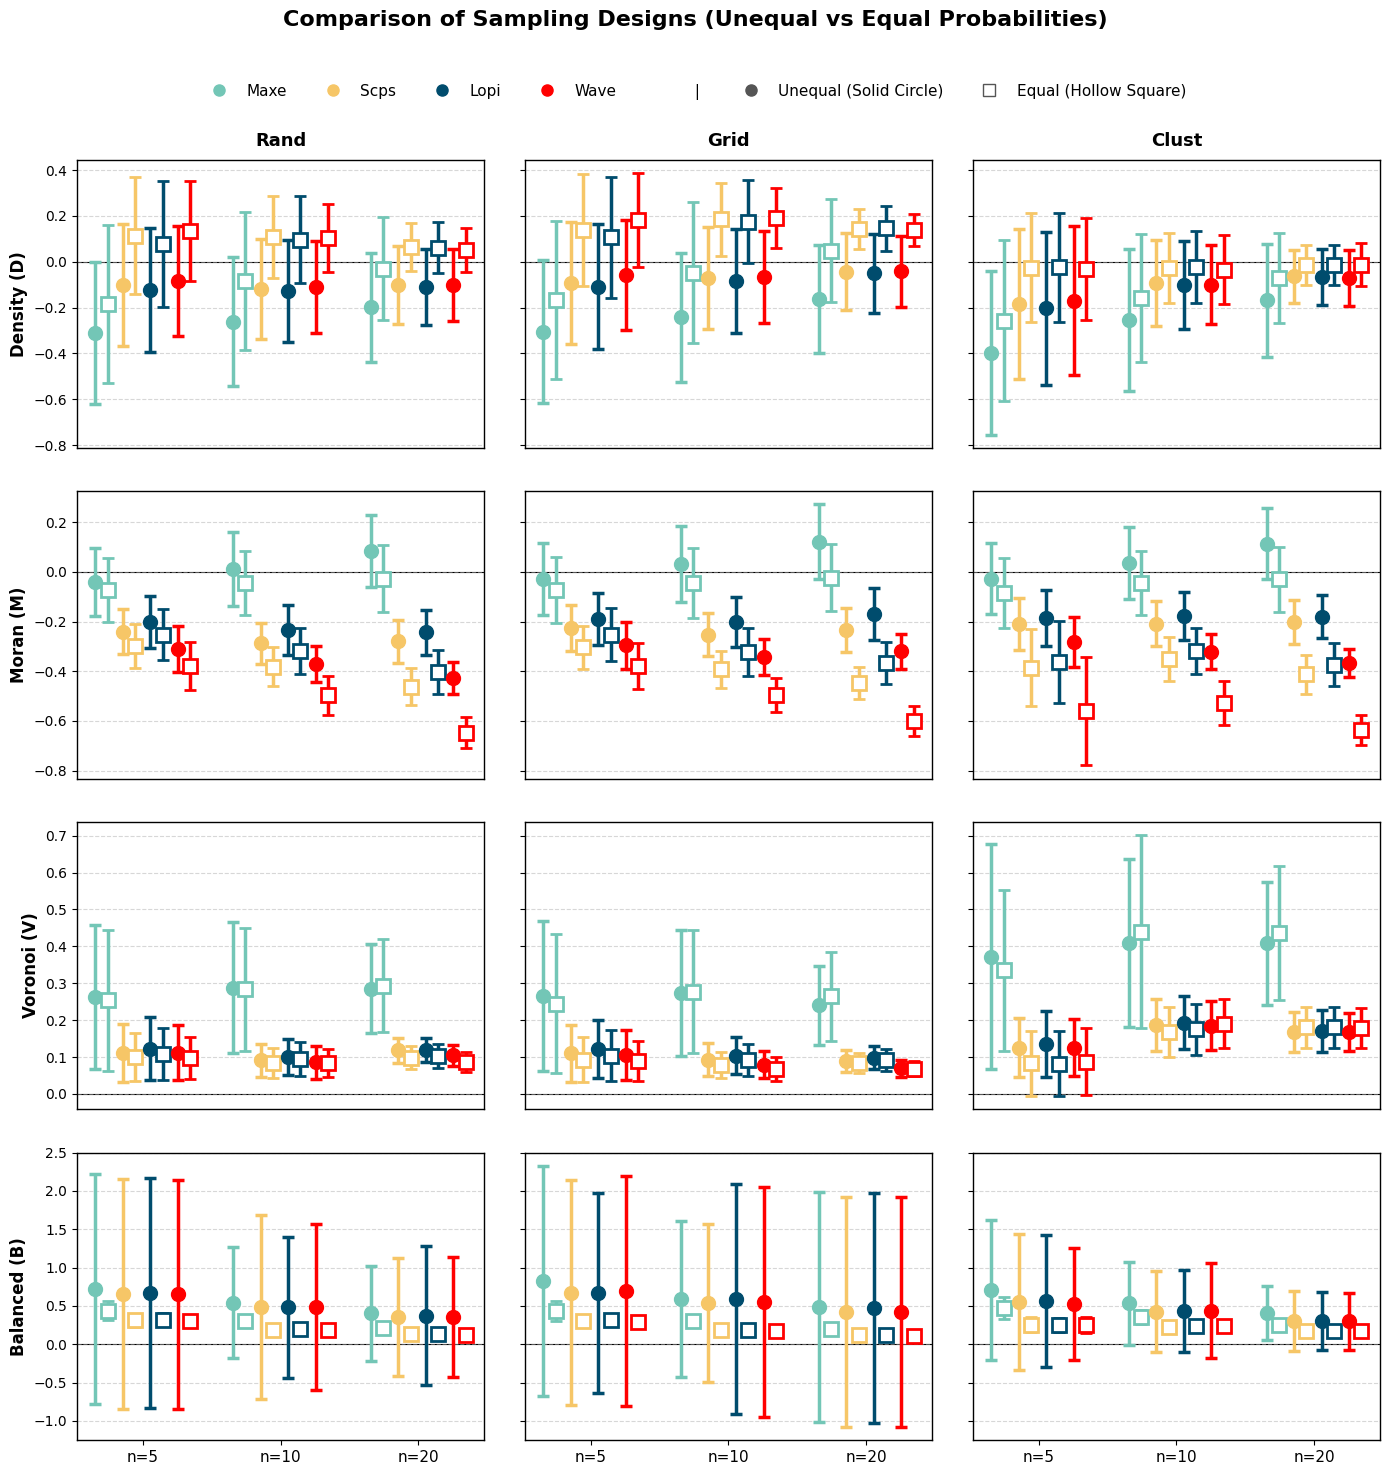

In [25]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

target_metrics = [
    ('Dm', 'Ds', 'Density (D)'),
    ('Mm', 'Ms', 'Moran (M)'),
    ('Vm', 'Vs', 'Voronoi (V)'),
    ('Lm', 'Ls', 'Balanced (B)')
]
target_populations = ['rand', 'grid', 'clust']

all_methods = ['Maxe', 'Scps', 'Lopi', 'Wave'] 

color_dict = {
    'Maxe': '#73c6b6',  # Pastel Indigo/Teal
    'Lopi': '#004c6d',  # Deep Ocean Blue
    'Scps': '#F6C667',  # Soft Amber
    'Wave': '#FF0000',  # Pure Red
}

fig, axes = plt.subplots(nrows=len(target_metrics), ncols=len(target_populations), 
                         figsize=(14, 15), sharey='row')

fig.suptitle("Comparison of Sampling Designs (Unequal vs Equal Probabilities)", 
             fontsize=16, fontweight='bold', y=0.98)

# Layout math: Every n has a cluster -> divided into Methods -> divided into 2 points (Unequal/Equal)
num_methods = len(all_methods)
total_cluster_width = 0.8
method_width = total_cluster_width / num_methods
bar_width = method_width * 0.45  # Keeps the spatial gap the same

for row_idx, (mean_col, std_col, metric_name) in enumerate(target_metrics):
    for col_idx, pop in enumerate(target_populations):
        ax = axes[row_idx, col_idx]
        pop_data = master_summary[master_summary['Population'] == pop]
        
        if pop_data.empty:
            ax.set_visible(False)
            continue
            
        n_vals = sorted(pop_data['n'].unique())
        x_pos = np.arange(len(n_vals))
        
        for i, method in enumerate(all_methods):
            m_data = pop_data[pop_data['Method'] == method]
            
            # Align perfectly by index 'n'
            un_data = m_data[m_data['Probability'] == 'Unequal'].set_index('n').reindex(n_vals)
            eq_data = m_data[m_data['Probability'] == 'Equal'].set_index('n').reindex(n_vals)
            
            # Shift the center for this specific method
            offset = (i - num_methods/2 + 0.5) * method_width
            
            # 1. Unequal (Solid Circle marker)
            yerr_un = un_data[std_col].values if std_col in un_data.columns else np.zeros(len(n_vals))
            ax.errorbar(x_pos + offset - bar_width/2, un_data[mean_col].values, 
                        yerr=yerr_un, fmt='o', color=color_dict[method], ecolor=color_dict[method], 
                        capsize=4, elinewidth=2.5, capthick=2.5, markersize=10, ls='none', zorder=3)
            
            # 2. Equal (Hollow Square marker)
            yerr_eq = eq_data[std_col].values if std_col in eq_data.columns else np.zeros(len(n_vals))
            ax.errorbar(x_pos + offset + bar_width/2, eq_data[mean_col].values, 
                        yerr=yerr_eq, fmt='s', mfc='white', color=color_dict[method], ecolor=color_dict[method], 
                        capsize=4, elinewidth=2.5, capthick=2.5, markersize=10, markeredgewidth=2.0, ls='none', zorder=3)
        # --- Formatting ---
        if row_idx == 0: ax.set_title(pop.capitalize(), fontsize=13, fontweight='bold', pad=10)
        if col_idx == 0: ax.set_ylabel(metric_name, fontsize=12, fontweight='bold')
            
        ax.set_xticks(x_pos)
        if row_idx == len(target_metrics) - 1:
            ax.set_xticklabels([f"n={nv}" for nv in n_vals], fontsize=11)
        else:
            ax.set_xticklabels([])
            ax.tick_params(axis='x', length=0)
            
        ax.axhline(0, color='black', linewidth=0.8, zorder=1)
        
        # Subtle gridlines to help read point values easily
        ax.grid(True, axis='y', linestyle='--', alpha=0.5, zorder=0)
        
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)

# Build a smart custom legend for points instead of bars
legend_elements = [mlines.Line2D([], [], color=color_dict[m], marker='o', linestyle='None', markersize=8, label=m) for m in all_methods]
legend_elements.append(mlines.Line2D([], [], color='white', label=' | ')) # spacer
legend_elements.append(mlines.Line2D([], [], color='#555555', marker='o', linestyle='None', markersize=8, label='Unequal (Solid Circle)'))
legend_elements.append(mlines.Line2D([], [], color='#555555', marker='s', mfc='white', linestyle='None', markersize=8, label='Equal (Hollow Square)'))

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.94), 
           ncol=len(legend_elements), fontsize=11, frameon=False)

plt.tight_layout()
plt.subplots_adjust(top=0.88, wspace=0.10, hspace=0.15)
plt.show()

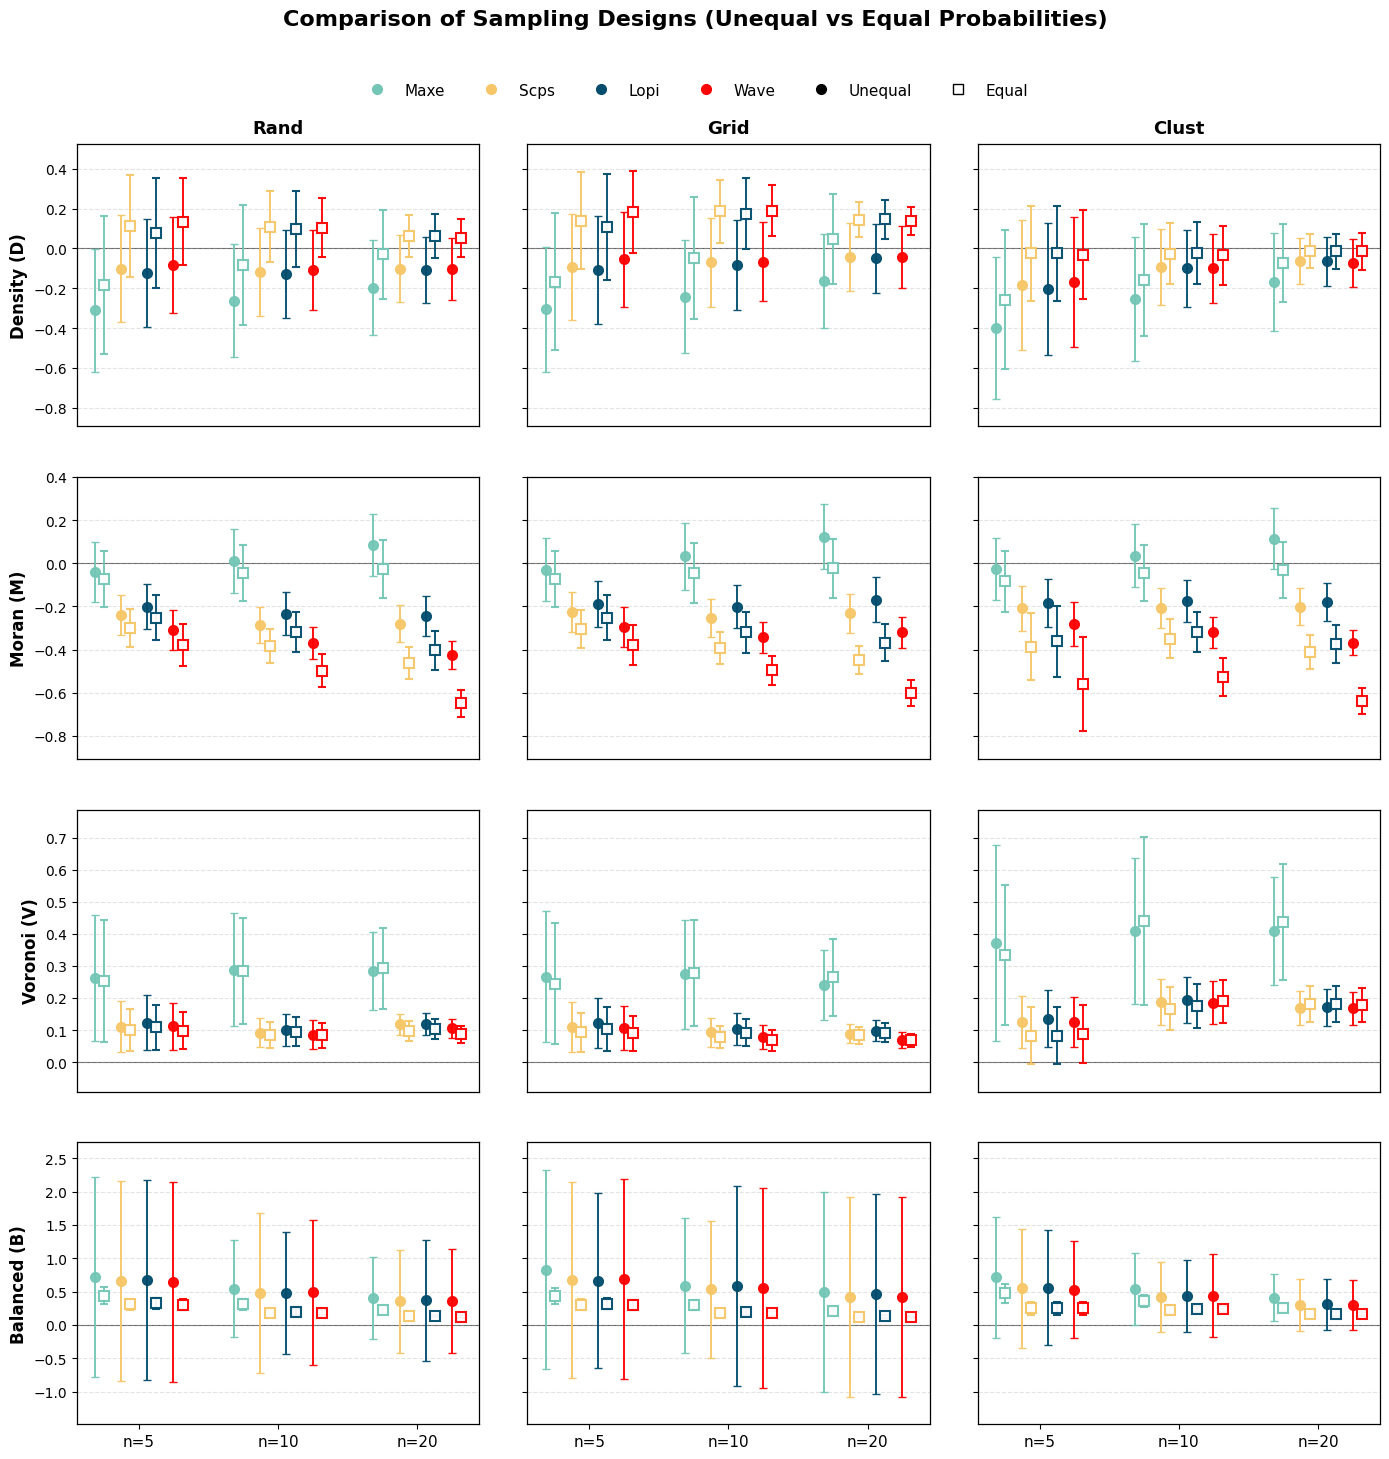

In [26]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

target_metrics = [
    ('Dm', 'Ds', 'Density (D)'),
    ('Mm', 'Ms', 'Moran (M)'),
    ('Vm', 'Vs', 'Voronoi (V)'),
    ('Lm', 'Ls', 'Balanced (B)')
]
target_populations = ['rand', 'grid', 'clust']
all_methods = ['Maxe', 'Scps', 'Lopi', 'Wave'] 

color_dict = {
    'Maxe': '#73c6b6',
    'Lopi': '#004c6d',
    'Scps': '#F6C667',
    'Wave': '#FF0000',
}

fig, axes = plt.subplots(
    nrows=len(target_metrics),
    ncols=len(target_populations),
    figsize=(14, 15),
    sharey='row'
)

fig.suptitle(
    "Comparison of Sampling Designs (Unequal vs Equal Probabilities)",
    fontsize=16,
    fontweight='bold',
    y=0.97
)

# ---------- GEOMETRY CONTROL ----------
num_methods = len(all_methods)

cluster_width = 0.75                 # slightly tighter overall cluster
method_spacing = cluster_width / num_methods
inner_sep = method_spacing * 0.35    # distance between equal/unequal
marker_size = 7                      # reduced marker size
err_linewidth = 1.4                  # thinner error bars
cap_size = 3                         # lighter caps

for row_idx, (mean_col, std_col, metric_name) in enumerate(target_metrics):
    for col_idx, pop in enumerate(target_populations):

        ax = axes[row_idx, col_idx]
        pop_data = master_summary[master_summary['Population'] == pop]

        if pop_data.empty:
            ax.set_visible(False)
            continue

        n_vals = sorted(pop_data['n'].unique())
        x_pos = np.arange(len(n_vals))

        for i, method in enumerate(all_methods):
            m_data = pop_data[pop_data['Method'] == method]

            un_data = (
                m_data[m_data['Probability'] == 'Unequal']
                .set_index('n')
                .reindex(n_vals)
            )

            eq_data = (
                m_data[m_data['Probability'] == 'Equal']
                .set_index('n')
                .reindex(n_vals)
            )

            # Better centered method offset
            method_offset = (i - (num_methods - 1)/2) * method_spacing

            x_un = x_pos + method_offset - inner_sep/2
            x_eq = x_pos + method_offset + inner_sep/2

            yerr_un = un_data[std_col].values if std_col in un_data else np.zeros(len(n_vals))
            yerr_eq = eq_data[std_col].values if std_col in eq_data else np.zeros(len(n_vals))

            # --- Unequal (solid circle) ---
            ax.errorbar(
                x_un,
                un_data[mean_col].values,
                yerr=yerr_un,
                fmt='o',
                color=color_dict[method],
                ecolor=color_dict[method],
                markersize=marker_size,
                elinewidth=err_linewidth,
                capsize=cap_size,
                alpha=0.95,
                zorder=3
            )

            # --- Equal (hollow square) ---
            ax.errorbar(
                x_eq,
                eq_data[mean_col].values,
                yerr=yerr_eq,
                fmt='s',
                mfc='white',
                markeredgewidth=1.5,
                color=color_dict[method],
                ecolor=color_dict[method],
                markersize=marker_size,
                elinewidth=err_linewidth,
                capsize=cap_size,
                alpha=0.95,
                zorder=3
            )

        # ---------------- Formatting ----------------

        if row_idx == 0:
            ax.set_title(pop.capitalize(), fontsize=13, fontweight='bold', pad=8)

        if col_idx == 0:
            ax.set_ylabel(metric_name, fontsize=12, fontweight='bold')

        ax.set_xticks(x_pos)

        if row_idx == len(target_metrics) - 1:
            ax.set_xticklabels([f"n={nv}" for nv in n_vals], fontsize=11)
        else:
            ax.set_xticklabels([])
            ax.tick_params(axis='x', length=0)

        ax.axhline(0, color='black', linewidth=0.8, alpha=0.6, zorder=1)

        # Softer grid
        ax.grid(True, axis='y', linestyle='--', alpha=0.35, zorder=0)

        # Subtle vertical margin so error bars breathe
        ax.margins(y=0.12)

        for spine in ax.spines.values():
            spine.set_linewidth(0.9)

# ---------------- Clean Legend ----------------

legend_elements = []

for m in all_methods:
    legend_elements.append(
        mlines.Line2D([], [], color=color_dict[m], marker='o',
                      linestyle='None', markersize=7, label=m)
    )

legend_elements.append(
    mlines.Line2D([], [], color='black', marker='o',
                  linestyle='None', markersize=7, label='Unequal')
)

legend_elements.append(
    mlines.Line2D([], [], color='black', marker='s',
                  mfc='white', linestyle='None',
                  markersize=7, label='Equal')
)

fig.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.93),
    ncol=6,
    fontsize=11,
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(top=0.88, wspace=0.12, hspace=0.18)
plt.show()


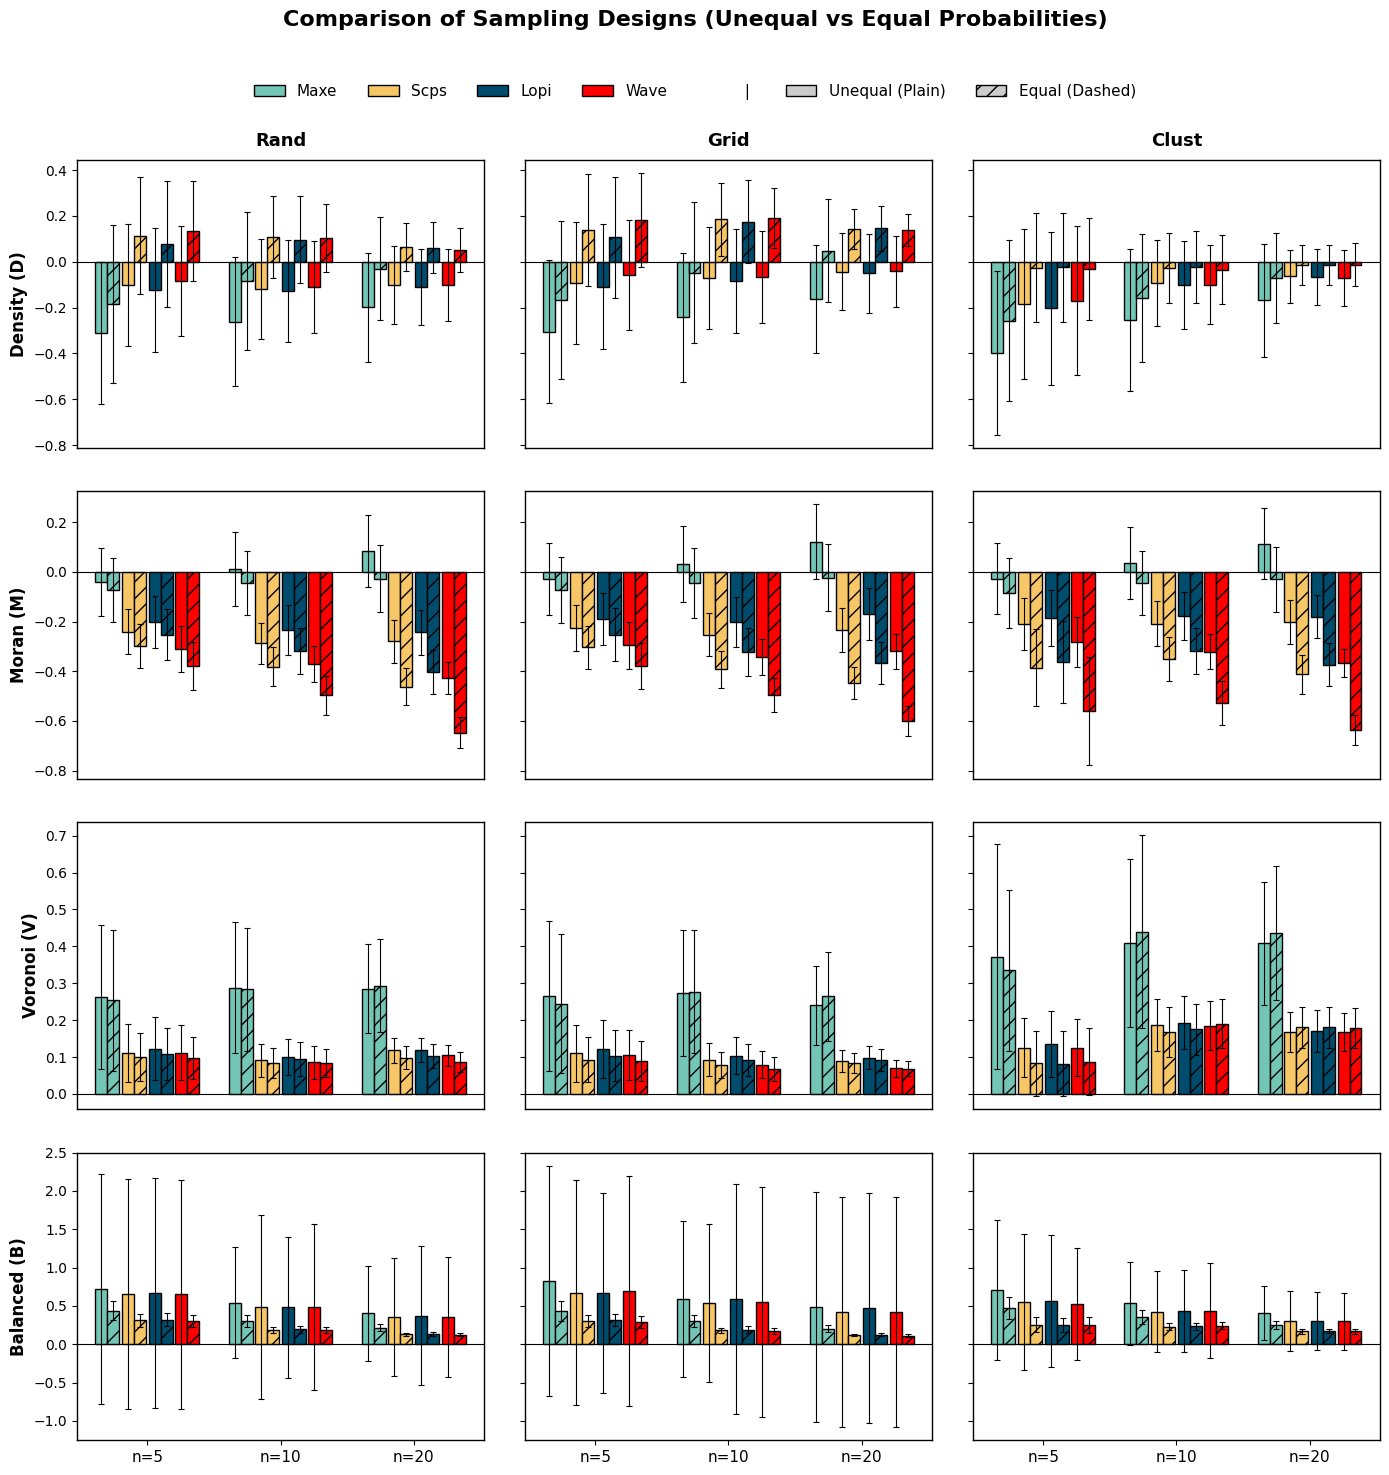

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

target_metrics = [
    ('Dm', 'Ds', 'Density (D)'),
    ('Mm', 'Ms', 'Moran (M)'),
    ('Vm', 'Vs', 'Voronoi (V)'),
    ('Lm', 'Ls', 'Balanced (B)')
]
target_populations = ['rand', 'grid', 'clust']

all_methods = ['Maxe', 'Scps', 'Lopi', 'Wave'] 

# colors = ['#8c6d51', '#f4d03f', '#73c6b6', '#e74c3c', '#3498db', '#9b59b6']
# color_dict = {method: colors[i % len(colors)] for i, method in enumerate(all_methods)}

color_dict = {
    'Maxe': '#73c6b6',  # Pastel Indigo
    'Lopi': '#004c6d',  # Pastel Green
    'Scps': '#F6C667',  # Soft Amber
    'Wave': '#FF0000',  # Pure Red
}
fig, axes = plt.subplots(nrows=len(target_metrics), ncols=len(target_populations), 
                         figsize=(14, 15), sharey='row')

fig.suptitle("Comparison of Sampling Designs (Unequal vs Equal Probabilities)", 
             fontsize=16, fontweight='bold', y=0.98)

# Layout math: Every n has a cluster -> divided into Methods -> divided into 2 bars (Unequal/Equal)
num_methods = len(all_methods)
total_cluster_width = 0.8
method_width = total_cluster_width / num_methods
bar_width = method_width * 0.45  # Leave a tiny pixel gap between the pair of bars

for row_idx, (mean_col, std_col, metric_name) in enumerate(target_metrics):
    for col_idx, pop in enumerate(target_populations):
        ax = axes[row_idx, col_idx]
        pop_data = master_summary[master_summary['Population'] == pop]
        
        if pop_data.empty:
            ax.set_visible(False)
            continue
            
        n_vals = sorted(pop_data['n'].unique())
        x_pos = np.arange(len(n_vals))
        
        for i, method in enumerate(all_methods):
            m_data = pop_data[pop_data['Method'] == method]
            
            # Align perfectly by index 'n'
            un_data = m_data[m_data['Probability'] == 'Unequal'].set_index('n').reindex(n_vals)
            eq_data = m_data[m_data['Probability'] == 'Equal'].set_index('n').reindex(n_vals)
            
            # Shift the center for this specific method
            offset = (i - num_methods/2 + 0.5) * method_width
            
            # 1. Unequal (Plain Bar - left side of the method slot)
            ax.bar(x_pos + offset - bar_width/2, un_data[mean_col].values, bar_width, 
                   yerr=un_data[std_col].values if std_col in un_data.columns else 0,
                   color=color_dict[method], edgecolor='black', capsize=2,
                   error_kw={'elinewidth': 0.8, 'capthick': 0.8})
            
            # 2. Equal (Hatched Bar - right side of the method slot)
            ax.bar(x_pos + offset + bar_width/2, eq_data[mean_col].values, bar_width, 
                   yerr=eq_data[std_col].values if std_col in eq_data.columns else 0,
                   color=color_dict[method], edgecolor='black', hatch='//', capsize=2,
                   error_kw={'elinewidth': 0.8, 'capthick': 0.8})
        
        # --- Formatting ---
        if row_idx == 0: ax.set_title(pop.capitalize(), fontsize=13, fontweight='bold', pad=10)
        if col_idx == 0: ax.set_ylabel(metric_name, fontsize=12, fontweight='bold')
            
        ax.set_xticks(x_pos)
        if row_idx == len(target_metrics) - 1:
            ax.set_xticklabels([f"n={nv}" for nv in n_vals], fontsize=11)
        else:
            ax.set_xticklabels([])
            ax.tick_params(axis='x', length=0)
            
        ax.axhline(0, color='black', linewidth=0.8, zorder=1)
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)

# Build a smart custom legend
legend_elements = [mpatches.Patch(facecolor=color_dict[m], edgecolor='black', label=m) for m in all_methods]
legend_elements.append(mpatches.Patch(facecolor='white', edgecolor='white', label=' | ')) # spacer
legend_elements.append(mpatches.Patch(facecolor='#cccccc', edgecolor='black', label='Unequal (Plain)'))
legend_elements.append(mpatches.Patch(facecolor='#cccccc', edgecolor='black', hatch='//', label='Equal (Dashed)'))

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.94), 
           ncol=len(legend_elements), fontsize=11, frameon=False)

plt.tight_layout()
plt.subplots_adjust(top=0.88, wspace=0.10, hspace=0.15)
plt.show()

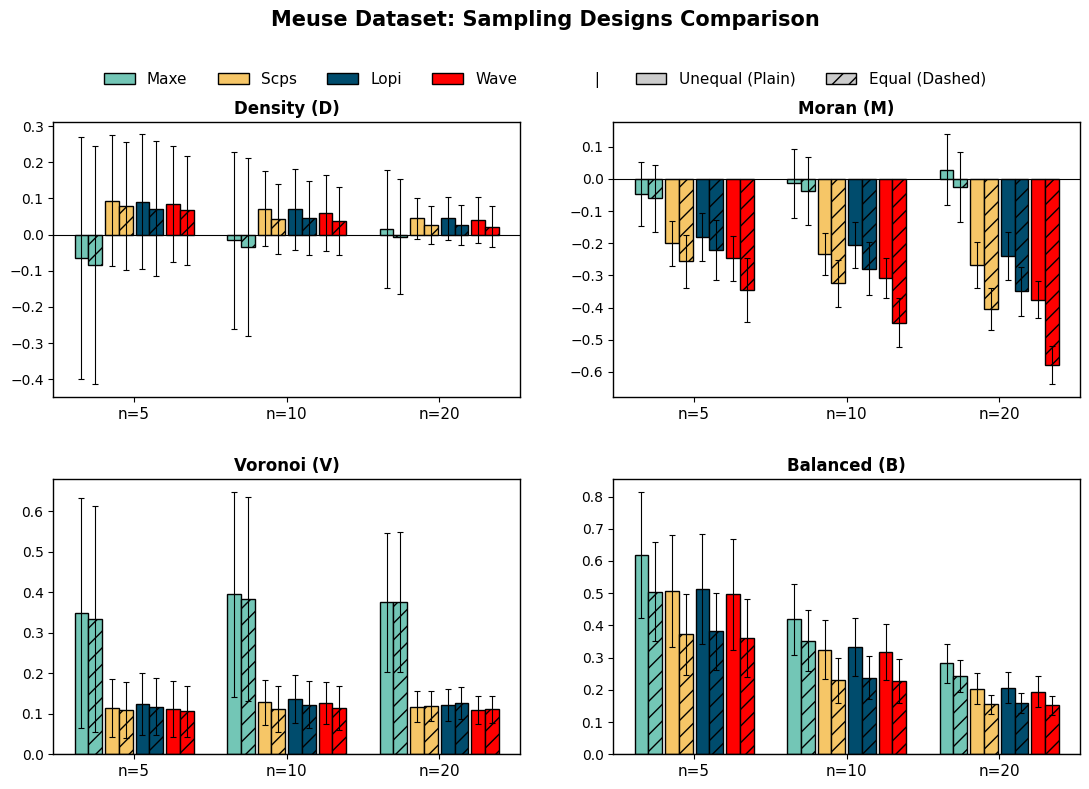

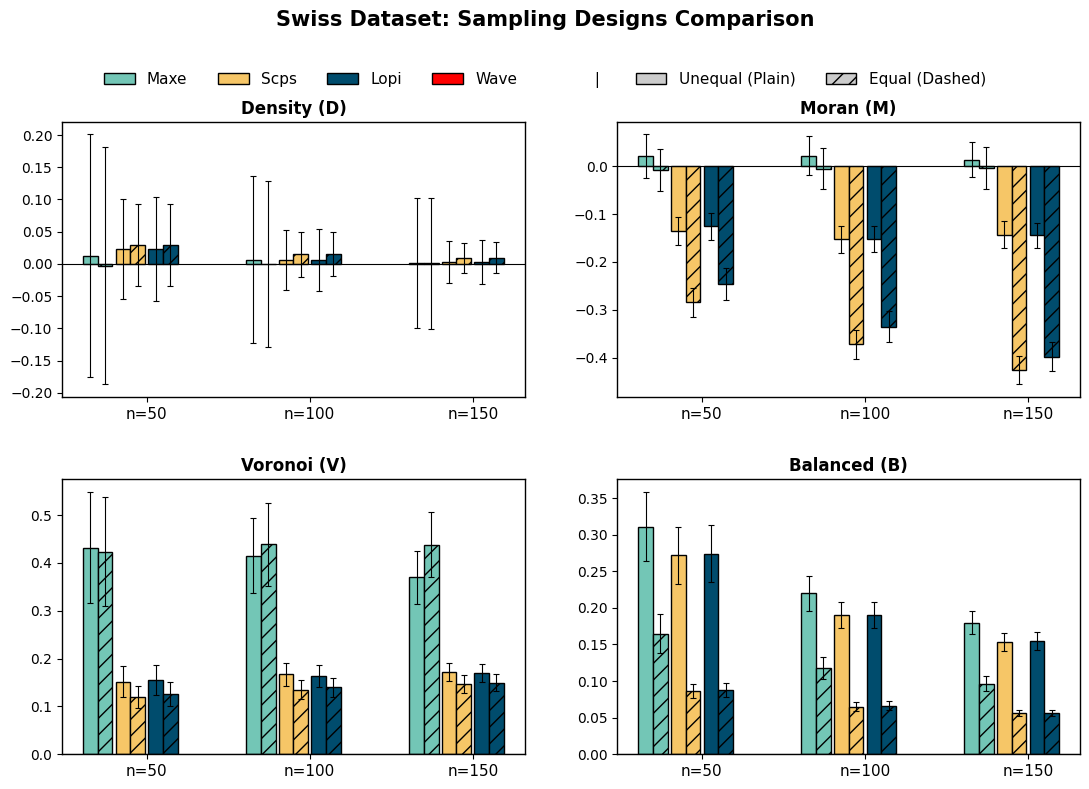

In [23]:
def plot_real_dataset_all_methods(dataset_name):
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(11, 8))
    fig.suptitle(f"{dataset_name.capitalize()} Dataset: Sampling Designs Comparison", 
                 fontsize=15, fontweight='bold', y=0.98)

    axes = axes.flatten()
    pop_data = master_summary[master_summary['Population'] == dataset_name]

    if pop_data.empty:
        print(f"Warning: No data found for '{dataset_name}' population.")
        return

    n_vals = sorted(pop_data['n'].unique())
    x_pos = np.arange(len(n_vals))
    
    method_width = 0.8 / len(all_methods)
    bar_width = method_width * 0.45

    for idx, (mean_col, std_col, metric_name) in enumerate(target_metrics):
        ax = axes[idx]
        
        for i, method in enumerate(all_methods):
            m_data = pop_data[pop_data['Method'] == method]
            un_data = m_data[m_data['Probability'] == 'Unequal'].set_index('n').reindex(n_vals)
            eq_data = m_data[m_data['Probability'] == 'Equal'].set_index('n').reindex(n_vals)
            
            offset = (i - len(all_methods)/2 + 0.5) * method_width
            
            # Unequal (Plain)
            ax.bar(x_pos + offset - bar_width/2, un_data[mean_col].values, bar_width, 
                   yerr=un_data[std_col].values if std_col in un_data.columns else 0,
                   color=color_dict[method], edgecolor='black', capsize=2,
                   error_kw={'elinewidth': 0.8, 'capthick': 0.8})
            
            # Equal (Hatched)
            ax.bar(x_pos + offset + bar_width/2, eq_data[mean_col].values, bar_width, 
                   yerr=eq_data[std_col].values if std_col in eq_data.columns else 0,
                   color=color_dict[method], edgecolor='black', hatch='//', capsize=2,
                   error_kw={'elinewidth': 0.8, 'capthick': 0.8})
        
        # --- Formatting ---
        ax.set_title(metric_name, fontsize=12, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels([f"n={nv}" for nv in n_vals], fontsize=11)
        ax.axhline(0, color='black', linewidth=0.8, zorder=1)
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)
            
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.92), 
               ncol=len(legend_elements), fontsize=11, frameon=False)

    plt.tight_layout()
    plt.subplots_adjust(top=0.84, wspace=0.20, hspace=0.30)
    plt.show()

# Run it for your datasets!
plot_real_dataset_all_methods('meuse')
plot_real_dataset_all_methods('swiss')
# plot_real_dataset_all_methods('swiss') # You can uncomment this to plot swiss too!

### Store

In [92]:
color_dict = {
    'Maxe': '#6C7CA2',  # Pastel Indigo (From your "MAX")
    'Lopi': '#7FB685',  # Red (From your "WAV" / what was red in your legend)
    'Scps': '#F6C667',  # Pastel Green (From your "LP1")
    'Wave': '#FF0000',  # Soft Orange (From your "NMS")
}

color_dict = {
    'Maxe': '#6C7CA2',  # Pastel Indigo
    'Lopi': '#F6C667',  # Pastel Green
    'Scps': '#7FB685',  # Soft Amber
    'Wave': '#FF0000',  # Pure Red
}


color_dict = {
    'Maxe': '#8D6E63',  # Pastel Indigo
    'Lopi': '#F6C667',  # Pastel Green
    'Scps': '#7FB685',  # Soft Amber
    'Wave': '#FF0000',  # Pure Red
}
    # "Autumn & Earth": ['#FFCA28', '', '', '', '#1E88E5', '#D81B60'],#E65100

# color_dict = {
#     'Maxe': '#5C6B8C',  # Deeper Slate Blue
#     'Lopi': '#6EA174',  # Sage Green
#     'Scps': '#E5B25D',  # Warm Gold
#     'Wave': '#D93838',  # Brick Red
# }

# color_dict = {
#     'Maxe': '#8D6E63',  # Muted Cocoa
#     'Lopi': '#FBC02D',  # Golden Yellow
#     'Scps': '#E65100',  # Burnt Orange
#     'Wave': '#C62828',  # Deep Crimson
# }

# color_dict = {
#     'Maxe': '#424242',  # Dark Charcoal
#     'Lopi': '#9E9E9E',  # Neutral Grey
#     'Scps': '#E0E0E0',  # Light Silver
#     'Wave': '#E53935',  # Striking Red
# }






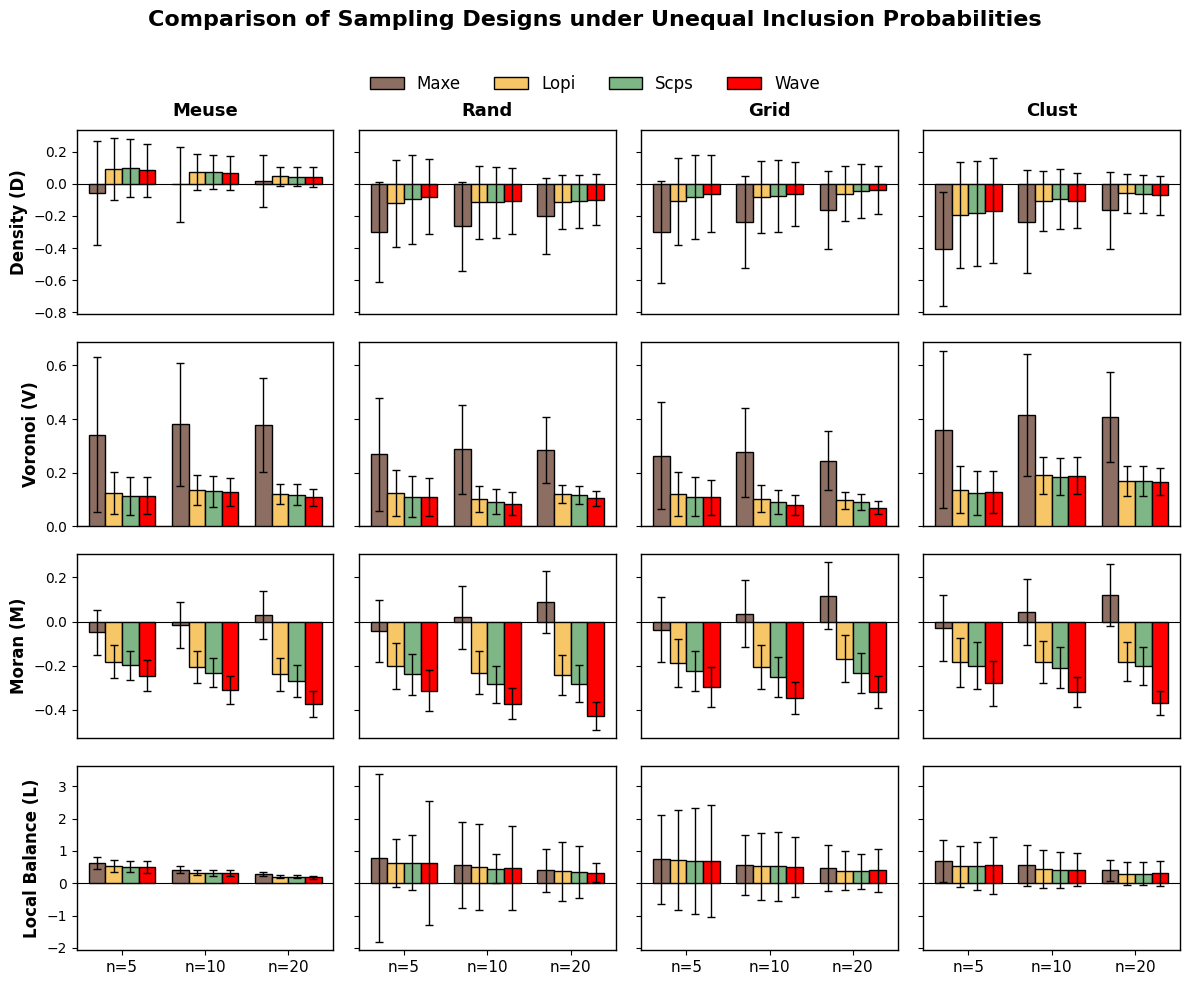

In [94]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. USER CONTROLS (Change these lists to reorder!)
# ==========================================

# 🔹 REARRANGE COLUMNS: Change the order of strings in this list to reorder your columns left-to-right
target_populations = ['meuse', 'rand', 'grid', 'clust'] 

# 🔹 REARRANGE ROWS: Change the order of these 4 lines to reorder your metrics top-to-bottom
target_metrics = [
    ('Dm', 'Ds', 'Density (D)'),
    ('Vm', 'Vs', 'Voronoi (V)'),
    ('Mm', 'Ms', 'Moran (M)'),
    ('Lm', 'Ls', 'Local Balance (L)')
]

# ==========================================
# 2. Data Preparation & Colors
# ==========================================

df_plot = master_summary[master_summary['Method'] != 'Rand'].copy()

# Ensure the populations actually exist in the data before plotting
pops = [p for p in target_populations if p in df_plot['Population'].unique()]

# Define Method Ordering
all_methods = df_plot['Method'].unique().tolist()
if 'Maxe' in all_methods:
    all_methods.remove('Maxe')
    methods_order = ['Maxe'] + sorted(all_methods) 
else:
    methods_order = sorted(all_methods)


# ==========================================
# 3. Plotting Engine
# ==========================================

fig, axes = plt.subplots(nrows=len(target_metrics), ncols=len(pops), figsize=(12, 10), sharey='row')

# Add the main overarching title
fig.suptitle("Comparison of Sampling Designs under Unequal Inclusion Probabilities", 
             fontsize=16, fontweight='bold', y=0.98)

for row_idx, (mean_col, std_col, metric_name) in enumerate(target_metrics):
    for col_idx, pop in enumerate(pops):
        ax = axes[row_idx, col_idx]
        
        pop_data = df_plot[df_plot['Population'] == pop]
        if pop_data.empty:
            ax.set_visible(False)
            continue
            
        n_vals = sorted(pop_data['n'].unique())
        x = np.arange(len(n_vals))
        width = 0.8 / len(methods_order) 
        
        for i, method in enumerate(methods_order):
            method_data = pop_data[pop_data['Method'] == method].set_index('n')
            method_data = method_data.reindex(n_vals) 
            
            means = method_data[mean_col].values
            stds = method_data[std_col].values
            
            offset = (i - len(methods_order)/2 + 0.5) * width
            
            ax.bar(x + offset, means, width, yerr=stds, 
                   label=method if (row_idx == 0 and col_idx == 0) else "", 
                   color=color_dict.get(method, '#888888'), 
                   capsize=3, edgecolor='black', linewidth=1.0, 
                   error_kw={'elinewidth': 1.0, 'capthick': 1.0}, zorder=3)
        
        # --- Formatting for the "Plain Sheet" Look ---
        if row_idx == 0:
            ax.set_title(pop.capitalize(), fontsize=13, fontweight='bold', pad=10)
        
        if col_idx == 0:
            ax.set_ylabel(metric_name, fontsize=12, fontweight='bold')
            
        ax.set_xticks(x)
        if row_idx == len(target_metrics) - 1:
            ax.set_xticklabels([f"n={nv}" for nv in n_vals], fontsize=11)
        else:
            ax.set_xticklabels([]) 
            ax.tick_params(axis='x', length=0) 
            
        ax.axhline(0, color='black', linewidth=0.8, zorder=1)
        
        # 1. Turn off all inner grid lines
        ax.grid(False) 
        
        # 2. Force the standard box border around the plot to stay visible
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)

# Add the master legend
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.93), ncol=len(methods_order), 
           fontsize=12, frameon=False)

plt.tight_layout()
# Adjust top spacing to make room for both the suptitle and the legend
plt.subplots_adjust(top=0.86, wspace=0.10, hspace=0.15) 
plt.show()

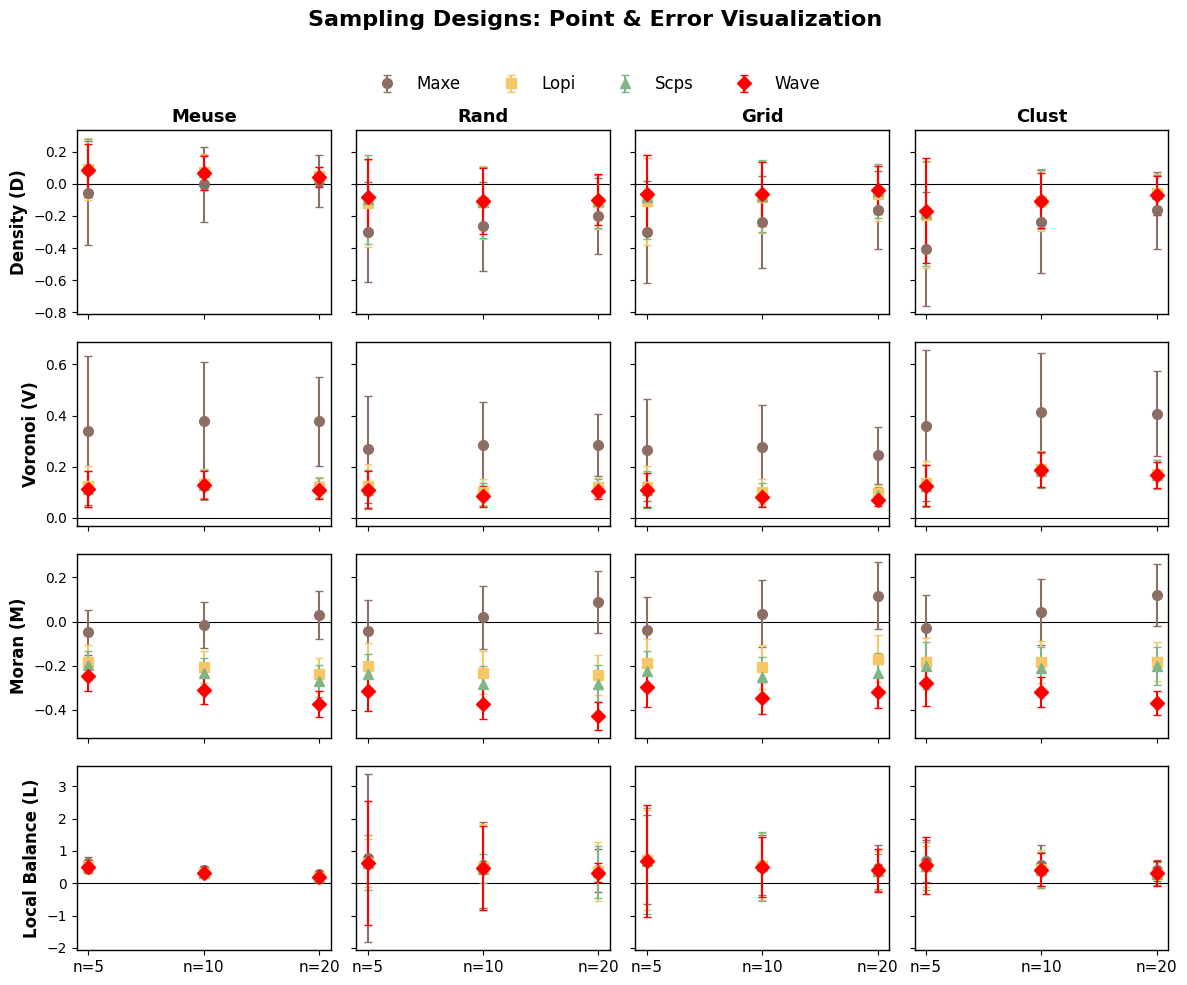

In [95]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(len(target_metrics), len(pops), figsize=(12, 10), sharey='row')
fig.suptitle("Sampling Designs: Point & Error Visualization", fontsize=16, fontweight='bold', y=0.98)

markers = ['o', 's', '^', 'D', 'P', '*', 'X']  # One per method

for row_idx, (mean_col, std_col, metric_name) in enumerate(target_metrics):
    for col_idx, pop in enumerate(pops):
        ax = axes[row_idx, col_idx]
        pop_data = df_plot[df_plot['Population'] == pop]
        if pop_data.empty:
            ax.set_visible(False)
            continue

        n_vals = sorted(pop_data['n'].unique())
        x = np.arange(len(n_vals))

        for i, method in enumerate(methods_order):
            method_data = pop_data[pop_data['Method'] == method].set_index('n').reindex(n_vals)
            means = method_data[mean_col].values
            stds = method_data[std_col].values
            ax.errorbar(x, means, yerr=stds, fmt=markers[i % len(markers)],
                        color=color_dict.get(method, '#888888'),
                        label=method if (row_idx == 0 and col_idx == 0) else "", capsize=3, markersize=7, zorder=3)

        if row_idx == 0:
            ax.set_title(pop.capitalize(), fontsize=13, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(metric_name, fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        if row_idx == len(target_metrics) - 1:
            ax.set_xticklabels([f"n={nv}" for nv in n_vals], fontsize=11)
        else:
            ax.set_xticklabels([])

        ax.axhline(0, color='black', linewidth=0.8, zorder=1)
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.93), ncol=len(methods_order), fontsize=12, frameon=False)
plt.tight_layout()
plt.subplots_adjust(top=0.86, wspace=0.10, hspace=0.15)
plt.show()

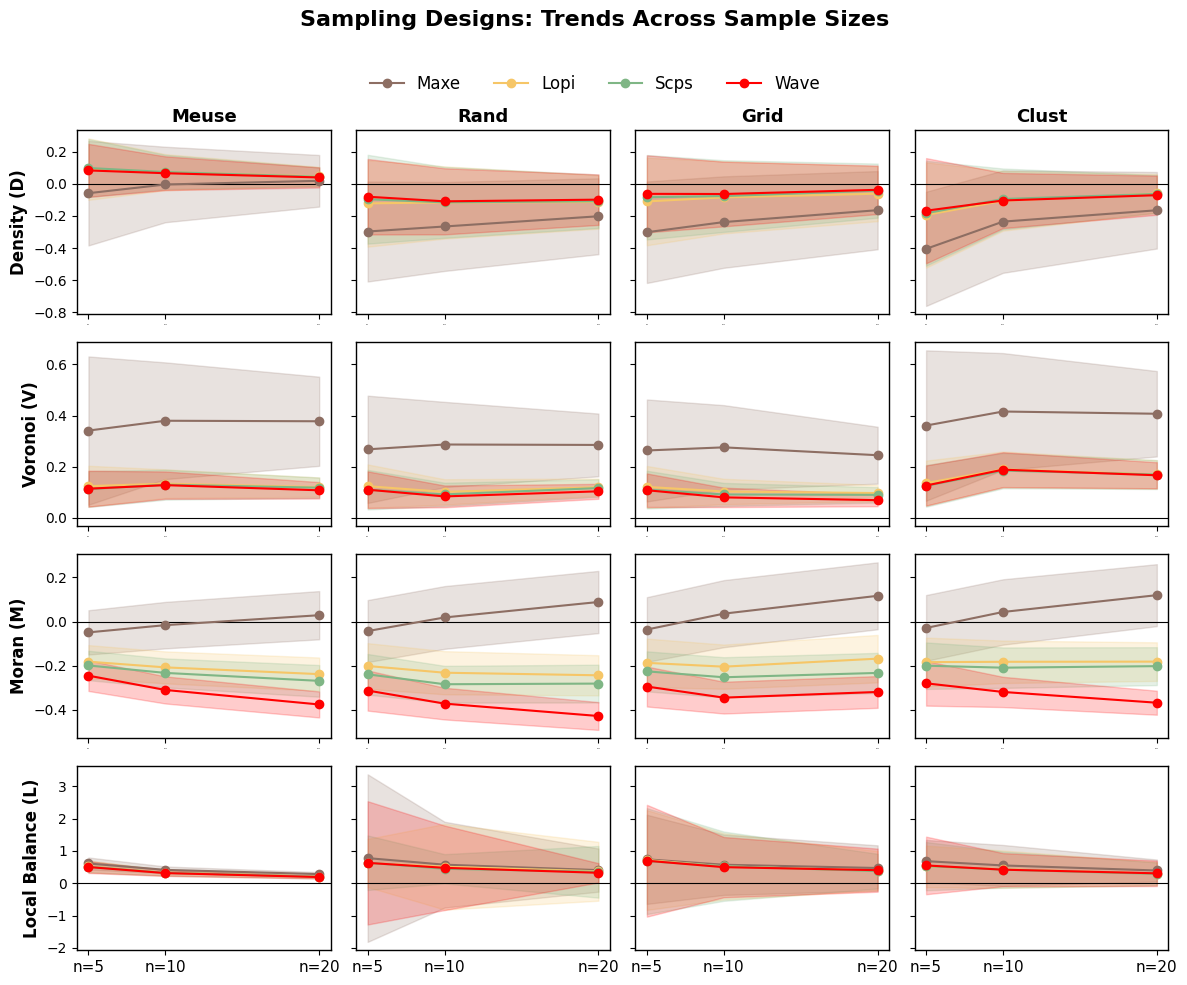

In [96]:
fig, axes = plt.subplots(len(target_metrics), len(pops), figsize=(12, 10), sharey='row')
fig.suptitle("Sampling Designs: Trends Across Sample Sizes", fontsize=16, fontweight='bold', y=0.98)

for row_idx, (mean_col, std_col, metric_name) in enumerate(target_metrics):
    for col_idx, pop in enumerate(pops):
        ax = axes[row_idx, col_idx]
        pop_data = df_plot[df_plot['Population'] == pop]
        if pop_data.empty:
            ax.set_visible(False)
            continue

        n_vals = sorted(pop_data['n'].unique())

        for i, method in enumerate(methods_order):
            method_data = pop_data[pop_data['Method'] == method].set_index('n').reindex(n_vals)
            means = method_data[mean_col].values
            stds = method_data[std_col].values
            ax.plot(n_vals, means, marker='o', color=color_dict.get(method, '#888888'),
                    label=method if (row_idx == 0 and col_idx == 0) else "", zorder=3)
            ax.fill_between(n_vals, means - stds, means + stds, color=color_dict.get(method, '#888888'), alpha=0.2)

        if row_idx == 0:
            ax.set_title(pop.capitalize(), fontsize=13, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(metric_name, fontsize=12, fontweight='bold')
        ax.set_xticks(n_vals)
        ax.set_xticklabels([f"n={nv}" for nv in n_vals], fontsize=11 if row_idx == len(target_metrics) - 1 else 0)

        ax.axhline(0, color='black', linewidth=0.8, zorder=1)
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.93), ncol=len(methods_order), fontsize=12, frameon=False)
plt.tight_layout()
plt.subplots_adjust(top=0.86, wspace=0.10, hspace=0.15)
plt.show()

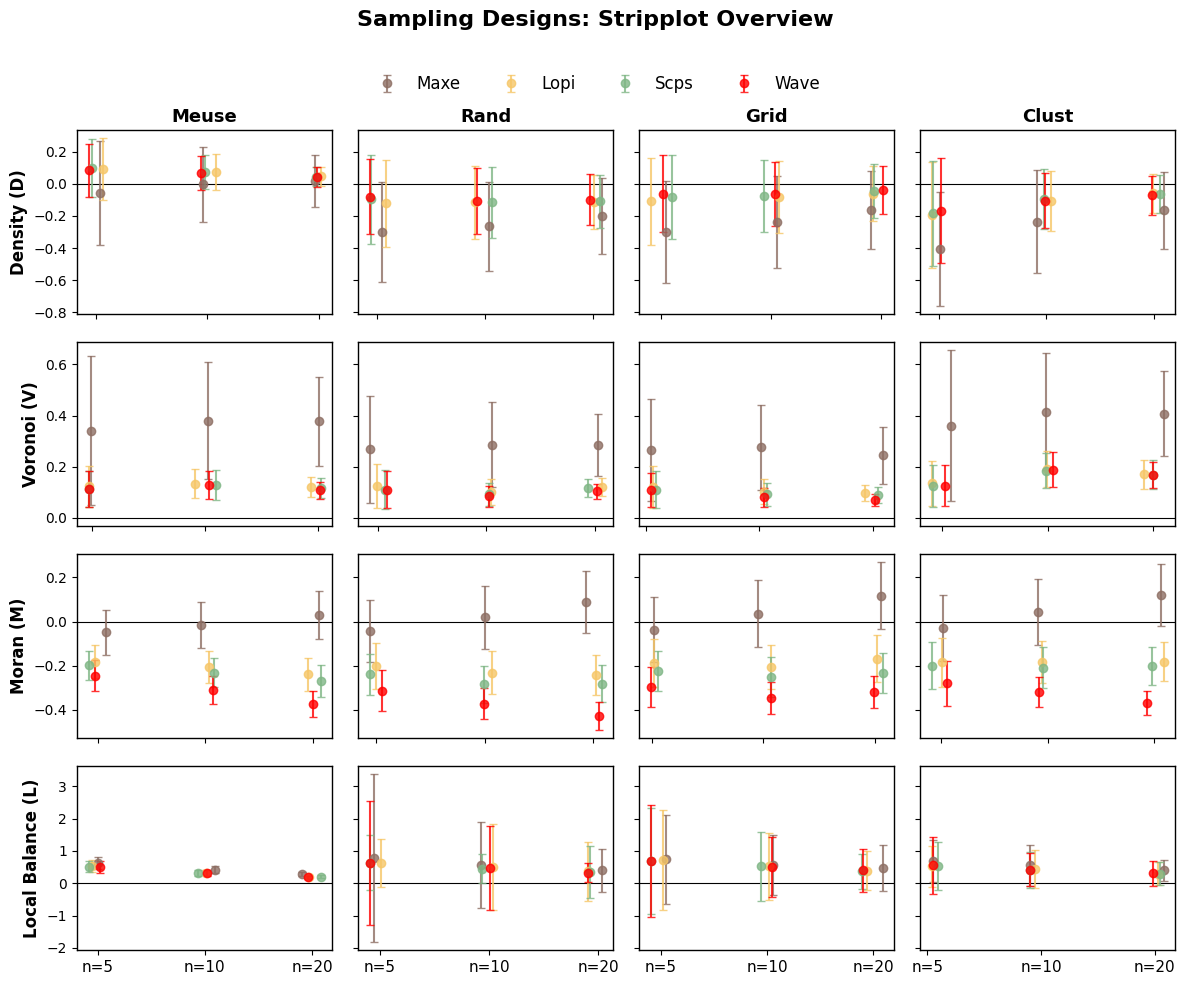

In [97]:
fig, axes = plt.subplots(len(target_metrics), len(pops), figsize=(12, 10), sharey='row')
fig.suptitle("Sampling Designs: Stripplot Overview", fontsize=16, fontweight='bold', y=0.98)

jitter_strength = 0.1

for row_idx, (mean_col, std_col, metric_name) in enumerate(target_metrics):
    for col_idx, pop in enumerate(pops):
        ax = axes[row_idx, col_idx]
        pop_data = df_plot[df_plot['Population'] == pop]
        if pop_data.empty:
            ax.set_visible(False)
            continue

        n_vals = sorted(pop_data['n'].unique())
        x_base = np.arange(len(n_vals))

        for i, method in enumerate(methods_order):
            method_data = pop_data[pop_data['Method'] == method].set_index('n').reindex(n_vals)
            means = method_data[mean_col].values
            stds = method_data[std_col].values
            jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(x_base))
            ax.errorbar(x_base + jitter, means, yerr=stds, fmt='o',
                        color=color_dict.get(method, '#888888'),
                        label=method if (row_idx == 0 and col_idx == 0) else "", capsize=3, markersize=6, alpha=0.8, zorder=3)

        if row_idx == 0:
            ax.set_title(pop.capitalize(), fontsize=13, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(metric_name, fontsize=12, fontweight='bold')
        ax.set_xticks(x_base)
        if row_idx == len(target_metrics) - 1:
            ax.set_xticklabels([f"n={nv}" for nv in n_vals], fontsize=11)
        else:
            ax.set_xticklabels([])

        ax.axhline(0, color='black', linewidth=0.8, zorder=1)
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.93), ncol=len(methods_order), fontsize=12, frameon=False)
plt.tight_layout()
plt.subplots_adjust(top=0.86, wspace=0.10, hspace=0.15)
plt.show()

### New plots

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# --- CELL 1: Read the Data ---

# Define the folder paths
folder_unequal = 'unequal_M=5000'  # You mentioned unequal_N=500 in the prompt
folder_equal = 'equal_M=5000'

def load_population_data(folder_path, prob_type):
    """
    Template function to read results from a folder.
    Adapt this based on how your files are structured (e.g., CSVs).
    """
    df_list = []
    if os.path.exists(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith('.csv'): # Assuming your results are in CSV files
                file_path = os.path.join(folder_path, file)
                df = pd.read_csv(file_path)
                df['Probability'] = prob_type
                
                # Tag the population type based on the filename
                for pop in ['rand', 'clust', 'grid', 'meuse']:
                    if pop in file.lower():
                        df['Population'] = pop
                        
                df_list.append(df)
        if df_list:
            return pd.concat(df_list, ignore_index=True)
        
    print(f"Warning: Folder '{folder_path}' not found or empty.")
    return pd.DataFrame()

# Load and combine datasets
df_unequal = load_population_data(folder_unequal, 'Unequal')
df_equal = load_population_data(folder_equal, 'Equal')

if not df_unequal.empty and not df_equal.empty:
    df_all = pd.concat([df_unequal, df_equal], ignore_index=True)
    print("Data successfully loaded!")
else:
    print("Please make sure your data folders exist and contain the files.")
    
# NOTE: In the plots below, dummy data is generated to show you the exact layout. 
# You will replace the dummy data variables with actual filtering from `df_all`.

Please make sure your data folders exist and contain the files.
